# Задача

Вычислить приближённо значение определённого интеграла с абсолютной погрешностью, не превышающей 10^-3 методами трапеций и парабол. Оценку погрешности выполнить практически и теоретически.


|Функция | a | b |
|---------|---|---|
| x^2 * exp(x) | 0 | 1 |


## Импорт зависимостей

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Определяем исходную функцию, а также функции расчёта приближённого значения интеграла

In [91]:
def foo(x):
    return x**2 * np.exp(x)

def trap(a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = foo(x)
    return h * (0.5 * (y[0] + y[-1]) + np.sum(y[1:-1]))

def simpson(a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = foo(x)
    s = 0
    for i in range(0, n, 2):
        s += (h/3) * (y[i] + 4*y[i+1] + y[i+2])

    return s

## Расчёт погрешностей

### Формулы на бумаге

Для метода трапеций: $|E| \leq \frac{(b-a)^3}{12n^2} \left[\max |f''(x)|\right]$

Для метода парабол: $|E| \leq \frac{(b-a)^5}{180n^4} \left[\max |f^{(4)}(x)|\right]$


### Функции в коде

In [92]:
def second_derivative(x):
    return 6*x*np.exp(x) + 6*np.exp(x)

def fourth_derivative(x):
    return 24*x*np.exp(x) + 96*np.exp(x) + 24*x**2*np.exp(x)

def trap_error(a, b, n):
    x = np.linspace(a, b, 100)
    max_second_derivative = np.max(np.abs(second_derivative(x)))
    return (max_second_derivative * (b-a)**3) / (12 * n**2)

def simpson_error(a, b, n):
    x = np.linspace(a, b, 100)
    max_fourth_derivative = np.max(np.abs(fourth_derivative(x)))
    return (max_fourth_derivative * (b-a)**5) / (180 * n**4)

## Вычисление N

In [93]:
def calculate_n_for_trap(a, b, tolerance):
    M = np.max(np.abs(second_derivative(x)))
    n = math.ceil(math.sqrt(((b - a)**3 * M) / (12 * tolerance)))
    return n

def calculate_n_for_simpson(a, b, tolerance):
    M = np.max(np.abs(fourth_derivative(x)))
    n = math.ceil(((b - a)**5 * M / (180 * tolerance))**(1/4))
    return n

## Запуск

In [94]:
a, b = 0, 1
acc = 10e-3
n_trap = calculate_n_for_trap(a, b, acc)
n_simpson = calculate_n_for_simpson(a, b, acc)

actual_value = (np.exp(1) - 2)

trap_result_practical = trap(a, b, n_trap)
simpson_result_practical = simpson(a, b, n_simpson)

trap_error_theoretical = trap_error(a, b, n_trap)
simpson_error_theoretical = simpson_error(a, b, n_simpson)

print(f"Для метода трапеций n={n_trap}")
print(f"Для метода парабол n={n_simpson}")
print(f"Реальное значение: {actual_value}")
print(f"Результат по методу трапеций: {trap_result_practical}")
print(f"Результат по методу парабол: {simpson_result_practical}")
print(f"Практическая ошибка, метод трапеций: {abs(trap_result_practical - actual_value)}")
print(f"Практическая ошибка, метод парабол: {abs(simpson_result_practical - actual_value)}")
print(f"Теоретическая ошибка, метод трапеций: {trap_error_theoretical}")
print(f"Теоретическая ошибка, метод парабол: {simpson_error_theoretical}")

Для метода трапеций n=17
Для метода парабол n=4
Реальное значение: 0.7182818284590451
Результат по методу трапеций: 0.7206327955535906
Результат по методу парабол: 0.7189082379466303
Практическая ошибка, метод трапеций: 0.0023509670945455197
Практическая ошибка, метод парабол: 0.0006264094875851889
Теоретическая ошибка, метод трапеций: 0.009405819475636835
Теоретическая ошибка, метод парабол: 0.008494630713934517


## График

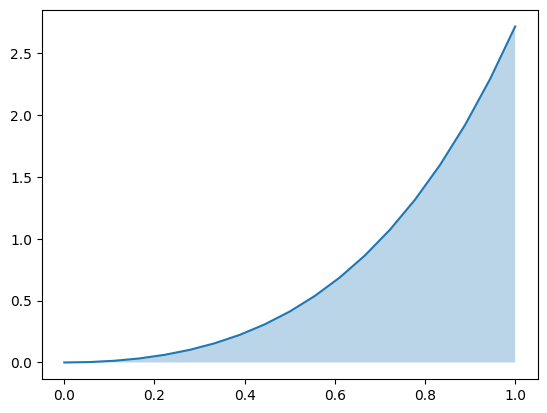

In [95]:
x = np.linspace(a, b, n + 1)
y = foo(x)

plt.plot(x, y)
plt.fill_between(x, 0, y, alpha=0.3)
plt.show()